# Example - Model-Based Feature Importance

This notebook demonstrates:
1. Training a regression model
2. Computing a model-based feature importance

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor, plot_tree

import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

print(df.head())
print(df.info())

   age  gender     bmi  children smoker     region  insurance_cost
0   18    male  33.770         1     no  southeast      1725.55230
1   18    male  34.100         0     no  southeast      1137.01100
2   18  female  26.315         0     no  northeast      2198.18985
3   18  female  38.665         2     no  northeast      3393.35635
4   18  female  35.625         0     no  northeast      2211.13075
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   gender          1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   insurance_cost  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


## 3. Basic Data Preparation Decisions

In [3]:
# Target variable
TARGET = "insurance_cost"

In [4]:
# Binary mapping for gender and smoker
df["gender"] = df["gender"].map({"male": 1, "female": 0})
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

In [5]:
# Discretise age into ordinal groups
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 30, 50, 100],
                          labels=[0, 1, 2])

df["age_group"] = df["age_group"].astype(int)

# Drop original age
df = df.drop(columns=["age"])

## 4. Features and Target

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [7]:
# Identify column types
numeric_features = ["bmi", "children", "age_group", "gender", "smoker"]
categorical_features = ["region"]

## 5. Data Preparation Pipeline

In [8]:
# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 6. Full Training Pipeline

In [9]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

## 7. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Train and Evaluate Model

In [11]:
pipe.fit(X_train, y_train)

# Evaluate
y_pred = pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")

R2: 0.86


## 9. Model-based Feature Importance

`DecisionTreeRegressor` provides `feature_importances_`. These importances are based on the total reduction in impurity contributed by each feature across the tree.

In [12]:
transformed_feature_names = pipe.named_steps["preprocessing"].get_feature_names_out()

tree_importances = pd.Series(
    pipe.named_steps["model"].feature_importances_,
    index=transformed_feature_names
).sort_values(ascending=False)

print("Decision tree feature importances:")
display(tree_importances)

Decision tree feature importances:


num__smoker              0.725951
num__bmi                 0.168115
num__age_group           0.098587
num__children            0.005529
cat__region_northeast    0.001179
num__gender              0.000639
cat__region_northwest    0.000000
cat__region_southeast    0.000000
cat__region_southwest    0.000000
dtype: float64

## 10. Plot

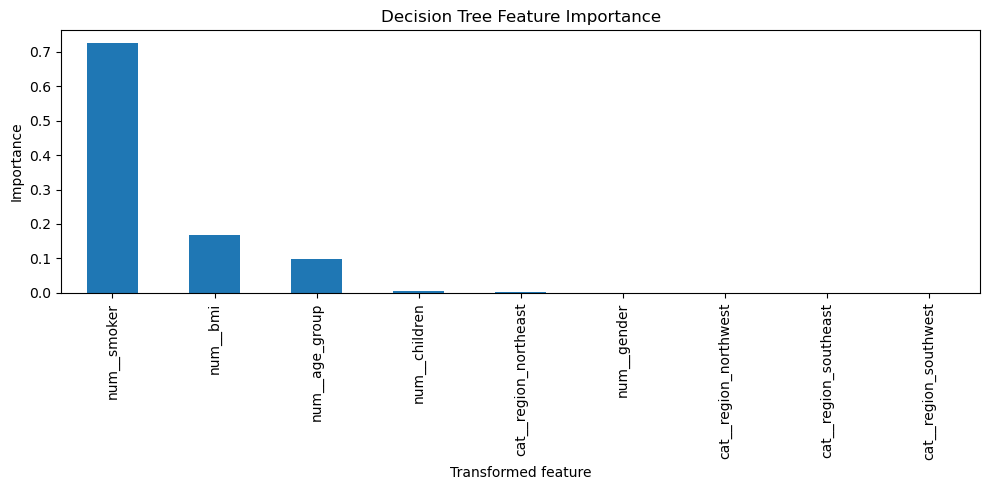

In [13]:
plt.figure(figsize=(10, 5))
tree_importances.plot(kind="bar")
plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Transformed feature")
plt.tight_layout()
plt.show()

## 11. Aggregate One-Hot Encoded Region Columns

Sometimes it is useful to combine the importances of all one-hot encoded columns that originate from the same original feature.

Aggregated feature importance by original feature:


original_feature
smoker       0.725951
bmi          0.168115
age_group    0.098587
children     0.005529
region       0.001179
gender       0.000639
Name: importance, dtype: float64

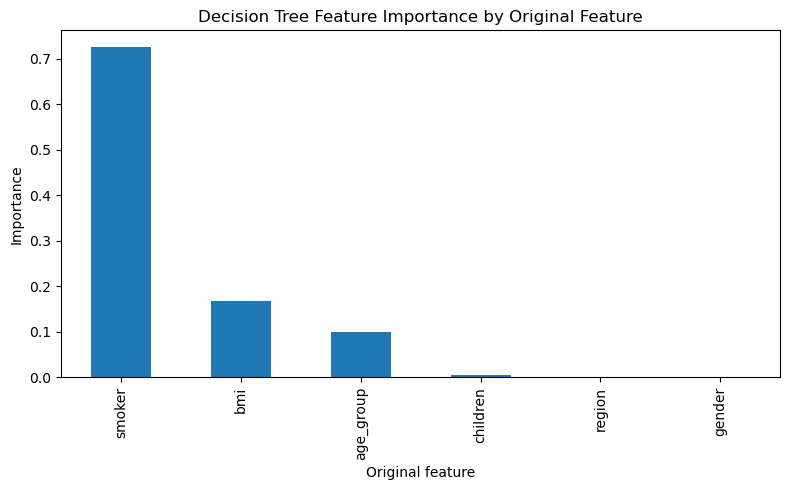

In [14]:
importance_df = tree_importances.reset_index()
importance_df.columns = ["feature", "importance"]

def recover_original_feature(name):
    if "region_" in name:
        return "region"
    elif "__" in name:
        return name.split("__")[-1]
    else:
        return name

importance_df["original_feature"] = importance_df["feature"].apply(recover_original_feature)

aggregated_importance = (
    importance_df.groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("Aggregated feature importance by original feature:")
display(aggregated_importance)

plt.figure(figsize=(8, 5))
aggregated_importance.plot(kind="bar")
plt.title("Decision Tree Feature Importance by Original Feature")
plt.ylabel("Importance")
plt.xlabel("Original feature")
plt.tight_layout()
plt.show()

# 12. Visualise the Decision Tree

A shallow tree can be plotted to inspect which features are used near the top.

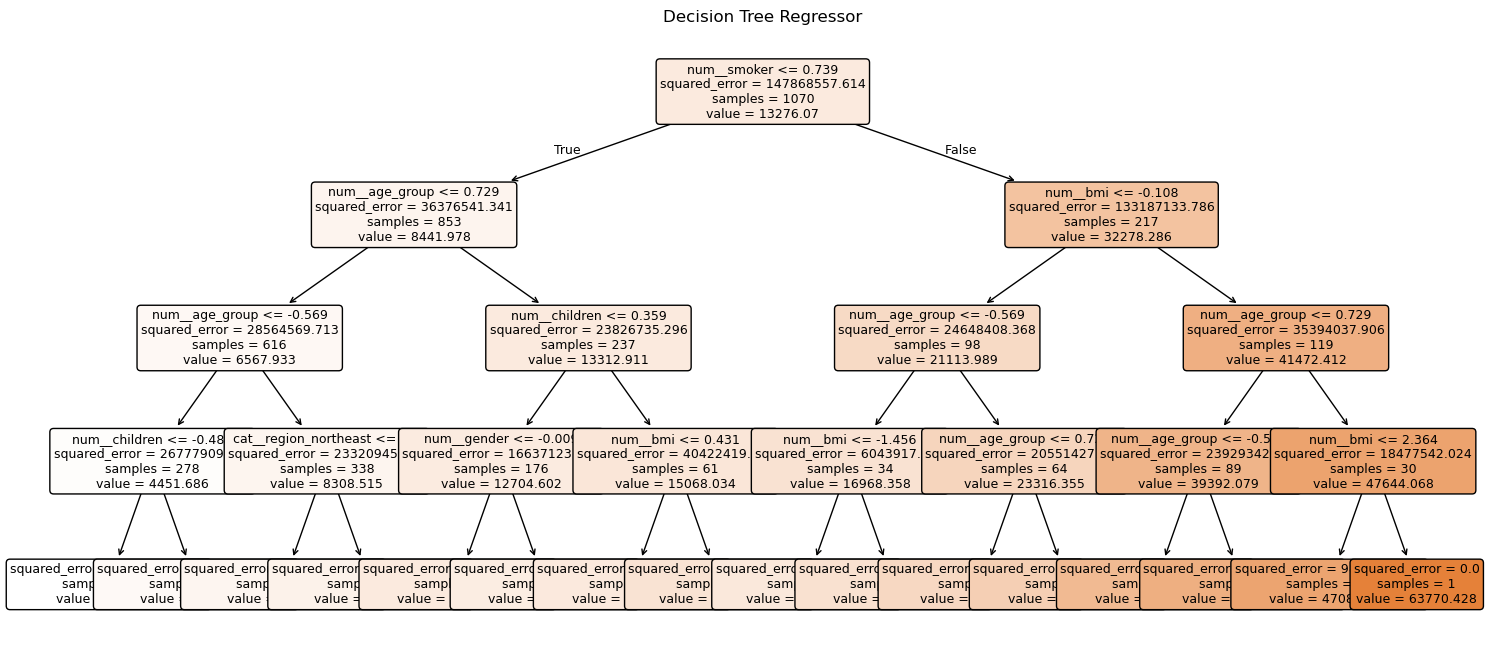

In [15]:
plt.figure(figsize=(18, 8))
plot_tree(
    pipe.named_steps["model"],
    feature_names=transformed_feature_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Regressor")
plt.show()

# 13. Interpretation Notes

- A higher importance means the feature contributed more to reducing impurity.
- Features used near the top of the tree often have high importance, but the importance depends on all splits, not just the root.
- Importance does not imply causation.
- For one-hot encoded features, the importance may be split across multiple columns.

## 14. Interpretation Questions

1. Which feature appears most important for `insurance_cost`?
2. Does this match your intuition about insurance costs?
3. Which region columns appear in the tree, if any?
4. Why is it useful to aggregate one-hot encoded region importances?
5. How do the importances change if you increase max_depth?
6. Would you expect a random forest to produce more stable importance estimates?